In [38]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
id_list = [925, 165, 9, 477, 291, 162]

In [40]:
nr_of_seeds = 10 #nr of seeds in the experiments
index = 162

In [41]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [42]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse']]
    return topk_d, topk_df

In [43]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_29996\3805261461.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_29996\3805261461.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'


<Axes: xlabel='method', ylabel='rmse'>

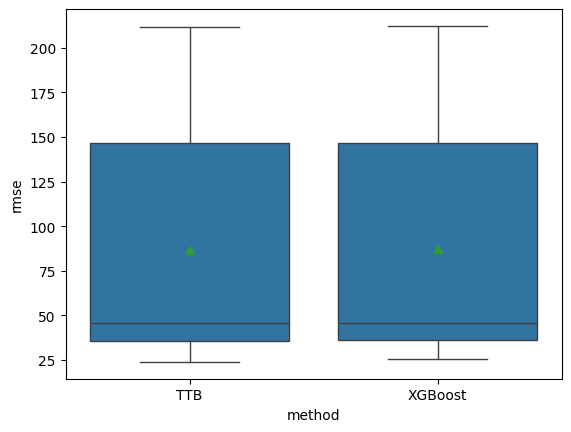

In [44]:


dat = pd.read_csv(f'results/ttb_LS_{index}.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb_{index}.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, lk = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

# data = pd.read_csv(f'results/two_trada_{index}.csv')
# trada_data = data
# trada_data['method'] = 'two-stage TrAdaBoost.R2'

# best_trada, jk = topk_per_d_per_method(
#     trada_data,
# ['method'], k=nr_of_seeds
# )
# best_trada['method'] = 'two-stage TrAdaBoost.R2'



df = best_LSTransferTreeBoost
#df = best_XGBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
#df = pd.concat([df, best_trada])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [45]:
best_params_for_us

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
286,0.1,1.0,1.0,0.05,0.5,86.76703,10,853.0,400.0,144.133331,46.144624,38.839434,25.239953,TransferTreeBoost
46,0.1,1.0,1.0,0.05,0.5,86.76703,10,850.0,400.0,25.131917,20.303032,211.648900,59.971363,TransferTreeBoost
625,0.1,1.0,1.0,0.05,0.5,86.76703,10,858.0,400.0,28.950771,27.427856,46.271669,37.716508,TransferTreeBoost
342,0.1,1.0,1.0,0.05,0.5,86.76703,10,854.0,400.0,30.252538,27.350241,143.945068,51.666288,TransferTreeBoost
574,0.1,1.0,1.0,0.05,0.5,86.76703,10,857.0,400.0,19.877895,16.552140,148.630410,58.349152,TransferTreeBoost
153,0.1,1.0,1.0,0.05,0.5,86.76703,10,852.0,400.0,34.440285,32.568557,34.324750,32.380904,TransferTreeBoost
110,0.1,1.0,1.0,0.05,0.5,86.76703,10,851.0,400.0,23.769701,21.840760,147.605686,54.628567,TransferTreeBoost
486,0.1,1.0,1.0,0.05,0.5,86.76703,10,856.0,400.0,143.971007,46.131644,26.865811,23.646798,TransferTreeBoost
417,0.1,1.0,1.0,0.05,0.5,86.76703,10,855.0,400.0,213.097188,58.671821,45.622142,24.980768,TransferTreeBoost
694,0.1,1.0,1.0,0.05,0.5,86.76703,10,859.0,400.0,211.988180,59.352828,23.916425,21.142213,TransferTreeBoost


In [46]:
lk

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
0,0.1,1.0,87.194503,10,0,850.0,28.464260,22.880479,212.333889,61.581118,XGBoost
6,0.1,1.0,87.194503,10,6,851.0,24.785232,22.650556,147.866469,55.221373,XGBoost
12,0.1,1.0,87.194503,10,12,852.0,35.041428,32.258865,34.949410,31.503803,XGBoost
18,0.1,1.0,87.194503,10,18,853.0,143.859769,47.613380,39.831731,26.430315,XGBoost
24,0.1,1.0,87.194503,10,24,854.0,31.143657,27.298632,143.815350,51.976001,XGBoost
30,0.1,1.0,87.194503,10,30,855.0,213.286344,59.057064,46.058598,25.907853,XGBoost
42,0.1,1.0,87.194503,10,42,857.0,20.118025,16.705990,148.168005,58.406593,XGBoost
36,0.1,1.0,87.194503,10,36,856.0,144.037159,46.117848,27.201316,23.285131,XGBoost
48,0.1,1.0,87.194503,10,48,858.0,30.516751,28.649976,45.974379,37.090035,XGBoost
54,0.1,1.0,87.194503,10,54,859.0,212.462687,59.558010,25.745879,21.901647,XGBoost


In [47]:
jk

NameError: name 'jk' is not defined